In [251]:
import pandas as pd
import scipy
import seaborn as sns
import numpy
import statsmodels
import statsmodels.api
import statsmodels.formula.api
import matplotlib.pyplot as plt

In [252]:
from scipy import stats


<h1>Data preparation<h1>

In [253]:
variables = ["kohde","jasen","pvknro","sp","IKAL1","ASALUE","V1","V21","V32","V40","H1a_A","H1h_A"]
#Documentation in habits.text
data=pd.read_csv("habits.data",delimiter=";",na_values="?")
print(data.count())

kohde     393
jasen     393
pvknro    393
sp        393
ASALUE    392
IKAL1     393
V1        391
V5        388
V7        389
V21       391
V22       391
V27       389
V32       388
V33       391
V40       390
V68       387
V69       389
V70       388
V75       386
H1a_A     369
H1b_A     367
H1g_A     369
H1h_A     370
H1i_A     368
dtype: int64


In [254]:
#remove extra variables
data=data[variables]

In [255]:
data.rename(columns={'pvknro':'day of week','sp': 'sex', 'IKAL1': 'age group', 'ASALUE': 'living environment', 'V1': 'working', 'V21': 'childcare', 'V32': 'sleeping', 'V33': 'dining', 'V40': 'studying in school', 'H1a_A': 'cinema', 'H1h_A': 'library'}, inplace=True)

In [256]:
data.keys()

Index(['kohde', 'jasen', 'day of week', 'sex', 'age group',
       'living environment', 'working', 'childcare', 'sleeping',
       'studying in school', 'cinema', 'library'],
      dtype='object')

In [257]:
def timeFormatter(time):
    temp=str(time)
    splits=temp.split(":")
    s=0
    for i in range(len(splits)):
        if(splits[i]!="nan" or None):
            #print("val ",splits[i])
            #print(time," : ",int(splits[i])*60**(len(splits)-1-i))
            s+=int(splits[i])*60**(len(splits)-1-i)
        else:
            print("invalid value : ", time)
    return s

    

In [258]:
data["sleeping"]=data["sleeping"].apply(timeFormatter)
data["working"]=data["working"].apply(timeFormatter)
data["childcare"]=data["childcare"].apply(timeFormatter)
data["studying in school"]=data["studying in school"].apply(timeFormatter)

invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan
invalid value :  nan


In [259]:
data["cinema"]=data["cinema"].astype("category")
data['cinema'] = data['cinema'].cat.rename_categories({ 1.0:'visited',  2.0:'not visited'})
data["library"]=data["library"].astype("category")
data['library'] = data['library'].cat.rename_categories({ 1.0:'visited',  2.0:'not visited',None:'unknown'})
data["living environment"]=data["living environment"].astype("category")
data["sex"]=data["sex"].astype("category")
data['sex'] = data['sex'].cat.rename_categories({ 1.0:'male',  2.0:'female', })
data['living environment'] = data['living environment'].cat.rename_categories({ 1.0:'city',  2.0:'munipality',  3.0:'rural'})

data["day of week"]=data["day of week"].astype("category")
data['day of week'] = data['day of week'].cat.rename_categories({ 1.0:'working day',  2.0:'weekend'})


data["age group"]=data["age group"].astype("category")
data['age group'] = data['age group'].cat.rename_categories({ 1.0:'10-14',  2.0:'15-19',3.0:'20-24 ', 4.0:'25-34 ',  5.0:'35-44',6.0:'45-54 ',7.0:'55-64 ',  8.0:'65-74 ', 9.0:'75-',})

data[data.notna()]
data.dtypes

kohde                    int64
jasen                    int64
day of week           category
sex                   category
age group             category
living environment    category
working                  int64
childcare                int64
sleeping                 int64
studying in school       int64
cinema                category
library               category
dtype: object

In [260]:
data=data.dropna()
data

,kohde,jasen,day of week,sex,age group,living environment,working,childcare,sleeping,studying in school,cinema,library
0,50007,2,weekend,female,45-54,rural,580,0,430,0,visited,visited
1,50009,1,working day,female,55-64,city,0,0,560,0,visited,visited
2,50015,1,working day,male,65-74,rural,0,0,450,0,not visited,visited
3,50032,2,working day,male,65-74,munipality,0,0,530,0,not visited,not visited
4,50033,1,working day,female,65-74,city,0,0,440,0,not visited,not visited
...,...,...,...,...,...,...,...,...,...,...,...,...
387,51923,1,weekend,male,65-74,city,0,0,660,0,not visited,not visited
388,51943,1,weekend,female,25-34,city,440,0,460,0,visited,not visited
389,51947,2,working day,female,55-64,city,490,0,470,0,visited,visited
390,51956,1,working day,female,45-54,munipality,0,0,0,0,visited,visited


In [261]:
print(data.count())
#nan values what to do with them?

#invalid entrys?
#suspicious values

kohde                 366
jasen                 366
day of week           366
sex                   366
age group             366
living environment    366
working               366
childcare             366
sleeping              366
studying in school    366
cinema                366
library               366
dtype: int64


# Question 1: Characterizing Individuals

IKAL1     int64
V1       object
V21      object
V32      object
V40      object
H1a_A    object
H1h_A    object
dtype: object
   IKAL1     V1    V21    V32    V40 H1a_A H1h_A
0      6    580      0    430      0   1.0   1.0
1      7      0      0    560      0   1.0   1.0
2      8      0      0    450      0   2.0   1.0
3      8      0      0    530      0   2.0   2.0
4      8  00:00  00:00  07:20  00:00   2.0   2.0
<class 'pandas.core.frame.DataFrame'>
Index: 310 entries, 0 to 391
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IKAL1   310 non-null    int64  
 1   V1      310 non-null    float64
 2   V21     310 non-null    float64
 3   V32     310 non-null    float64
 4   V40     310 non-null    float64
 5   H1a_A   310 non-null    float64
 6   H1h_A   310 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 19.4 KB
None


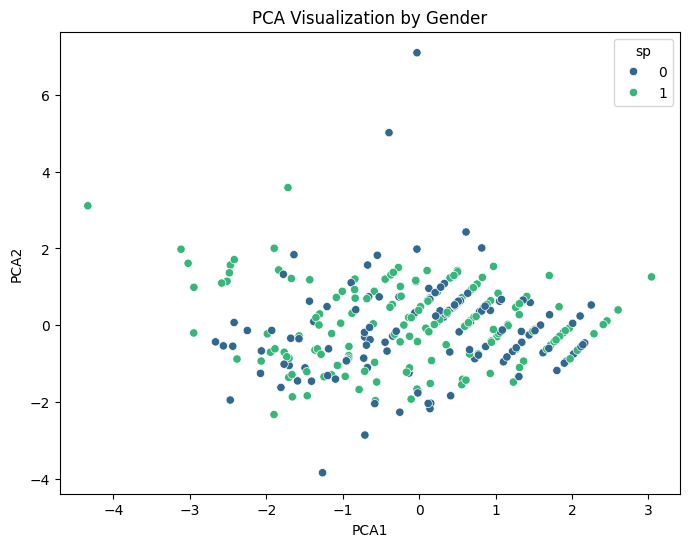

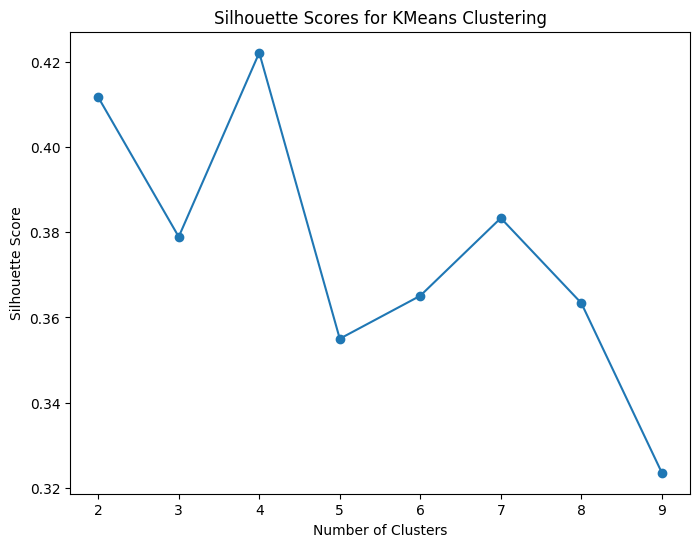

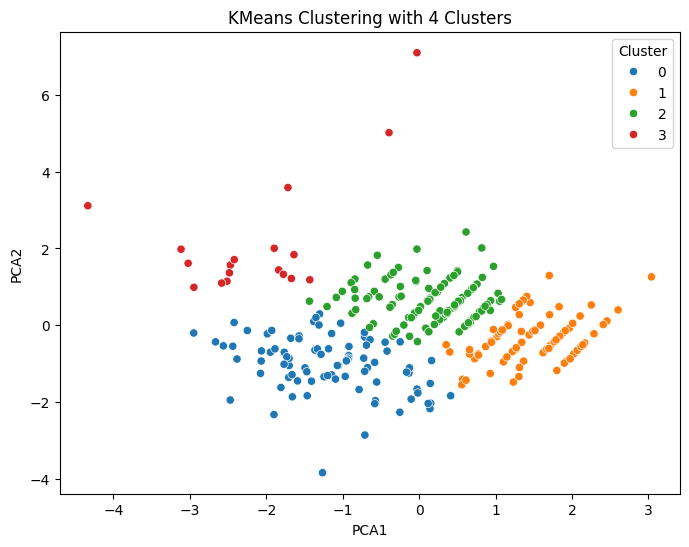

Cluster Characteristics:
                kohde     jasen    pvknro        sp     IKAL1    ASALUE  \
Cluster                                                                   
0        51018.620690  1.344828  1.551724  0.494253 -0.565846  0.712644   
1        50940.234568  1.395062  1.555556  0.530864  0.894092  0.691358   
2        50906.677419  1.451613  1.532258  0.564516 -0.066731  0.524194   
3        50925.444444  1.333333  1.222222  0.777778 -0.828786  0.722222   

               V1       V21       V32       V40     H1a_A     H1h_A      PCA1  \
Cluster                                                                         
0        1.313136  0.021843 -0.765393 -0.097689 -0.110421 -0.191868 -1.155221   
1       -0.463164 -0.276212  0.206339 -0.097689 -0.089615  1.234871  1.481597   
2       -0.559837 -0.195614  0.400527 -0.097689 -0.116822 -0.521641  0.151355   
3       -0.405931  2.484943  0.011688  1.584731  1.741745 -1.036036 -2.126287   

             PCA2  
Cluster          

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load data
file_path = r"habits.data"  # Adjust path as needed
data = pd.read_csv(file_path, sep=';')  # Assuming tab-separated file

# Select required columns
columns_to_use = ["kohde", "jasen", "pvknro", "sp", "IKAL1", "ASALUE", "V1", "V21", "V32", "V40", "H1a_A", "H1h_A"]
data = data[columns_to_use]

# Data preprocessing
# Handle missing values (drop rows with missing data for simplicity)
data = data.dropna()

# Encode categorical variables (e.g., gender and living area)
data["sp"] = data["sp"].astype('category').cat.codes  # Encode gender
data["ASALUE"] = data["ASALUE"].astype('category').cat.codes  # Encode living area

# Standardize numerical variables
scaler = StandardScaler()
numerical_columns = ["IKAL1", "V1", "V21", "V32", "V40", "H1a_A", "H1h_A"]

print(data[numerical_columns].dtypes)
print(data[numerical_columns].head())
for col in numerical_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data = data.dropna(subset=numerical_columns)
print(data[numerical_columns].info())

data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

# Dimensionality reduction with PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data[numerical_columns])
data["PCA1"] = data_pca[:, 0]
data["PCA2"] = data_pca[:, 1]

# Visualize PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PCA1", y="PCA2", hue="sp", data=data, palette="viridis")
plt.title("PCA Visualization by Gender")
plt.show()

# Clustering using KMeans
# Determine the optimal number of clusters using the silhouette score
range_n_clusters = range(2, 10)
silhouette_scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(data_pca)
    silhouette_avg = silhouette_score(data_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot silhouette scores
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title("Silhouette Scores for KMeans Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

# Choose optimal number of clusters (e.g., highest silhouette score)
optimal_clusters = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
data["Cluster"] = kmeans.fit_predict(data_pca)

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=data, palette="tab10")
plt.title(f"KMeans Clustering with {optimal_clusters} Clusters")
plt.show()

# Characterize clusters
cluster_characteristics = data.groupby("Cluster").mean()
print("Cluster Characteristics:")
print(cluster_characteristics)

# Question 2: Estimate the Average Daily Time Households Spend on Each Activity

In [ ]:
# Function to convert time strings (e.g., "07:20") to minutes
def time_to_minutes(value):
    try:
        if isinstance(value, str) and ":" in value:
            hours, minutes = map(int, value.split(":"))
            return hours * 60 + minutes
        return int(value)
    except ValueError:
        return None

# Clean the time-based variables
time_vars = ["working", "childcare", "sleeping", "studying in school"]
for var in time_vars:
    data[var] = data[var].apply(time_to_minutes)

# Calculate mean time for each activity
activity_means = data[time_vars].mean()

# Print results
print("Average Time Spent on Activities (in minutes):")
print(activity_means)

# Visualize average time spent
activity_means.plot(kind='bar', color='skyblue', figsize=(8, 6))
plt.title('Average Daily Time Spent on Activities')
plt.ylabel('Minutes')
plt.xlabel('Activities')
plt.xticks(rotation=45)
plt.show()

# <h1>Question 3: With respect to which activities do men and women differ?<h1>


<h2>working<h2>

In [212]:
data.groupby("sex")["working"].mean()

C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\2803810231.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sex")["working"].mean()


sex
male      149.754601
female    109.655172
Name: working, dtype: float64

0.21928772210291791
0.5909543031702043


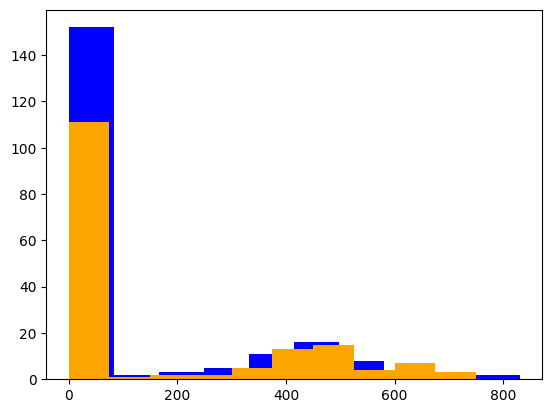

In [213]:
plt.hist(data[data["sex"]=="female"]["working"],color ='blue')
plt.hist(data[data["sex"]=="male"]["working"],color ='orange')

d1=data.loc[(data["sex"] == "female")& (data["working"] > 0) , "working"]
m=d1.mean()
std=d1.std()
print(scipy.stats.kstest(d1,"norm",(m,std))[1])
d2=data.loc[(data["sex"] == "male")& (data["working"] > 0) , "working"]
m=d2.mean()
std=d2.std()
print(scipy.stats.kstest(d2,"norm",(m,std))[1])

Based on Kolmogorow-Smirnov test p>0.05 and visual inspection the data is normally distributed. (and not paired if not working are excluded  thus we can use t-test to find if there are statistical differences)

(array([ 2.,  3.,  2.,  5., 11., 13.,  4.,  4.,  5.,  3.]),
 array([140., 201., 262., 323., 384., 445., 506., 567., 628., 689., 750.]),
 <BarContainer object of 10 artists>)

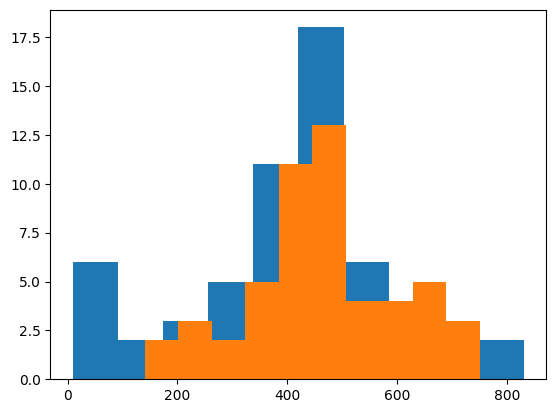

In [214]:

plt.hist(data.loc[(data["sex"] == "female") & (data["working"] > 0), "working"])
plt.hist(data.loc[(data["sex"] == "male") & (data["working"] > 0), "working"])

In [215]:
scipy.stats.ttest_ind(d1,d2)

TtestResult(statistic=np.float64(-2.5088765518231866), pvalue=np.float64(0.013611095501078274), df=np.float64(107.0))

With p<0.05 there is a statistically significant difference in time worked between man and women.

<h2>Childcare<h2>

(array([4., 2., 4., 1., 1., 1., 0., 1., 1., 2.]),
 array([ 10.,  24.,  38.,  52.,  66.,  80.,  94., 108., 122., 136., 150.]),
 <BarContainer object of 10 artists>)

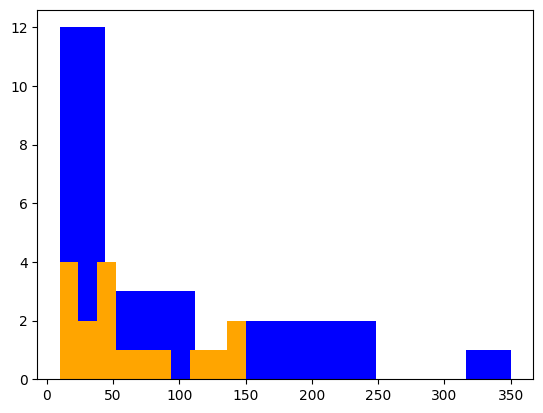

In [216]:
plt.hist(data.loc[(data["sex"] == "female") & (data["childcare"] > 0), "childcare"],color ='blue')
plt.hist(data.loc[(data["sex"] == "male") & (data["childcare"] > 0), "childcare"],color ='orange')

0.1416149834136501
0.41057995488071963


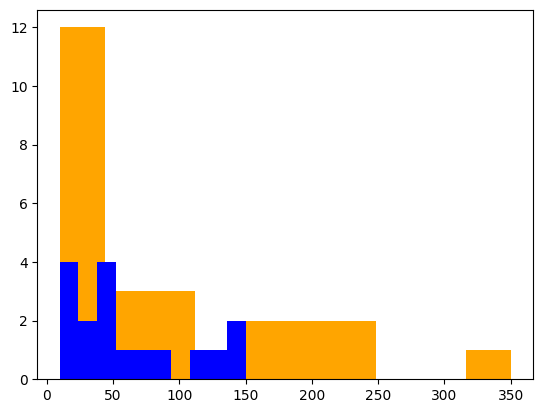

In [217]:
plt.hist(data.loc[(data["sex"] == "female")& (data["childcare"] > 0) , "childcare"],color ='orange')
plt.hist(data.loc[(data["sex"] == "male")& (data["childcare"] > 0) , "childcare"],color ='blue')


d1=data.loc[(data["sex"] == "female")& (data["childcare"] > 0) , "childcare"]
m=d1.mean()
std=d1.std()
print(scipy.stats.kstest(d1,"norm",(m,std))[1])
d2=data.loc[(data["sex"] == "male")& (data["childcare"] > 0) , "childcare"]
m=d2.mean()
std=d2.std()
print(scipy.stats.kstest(d2,"norm",(m,std))[1])

Without zeros the kstest indicates that the data is normally distributed however upon visual inspection the distribution looks a lot more like a exponential distribution so a Wilcoxon-Man might be more appropriete than a t-test.

In [218]:
print(scipy.stats.mannwhitneyu(d1,d2))

MannwhitneyuResult(statistic=np.float64(247.5), pvalue=np.float64(0.5167147611642209))


3.838574330363142e-43
1.7396235129905034e-38


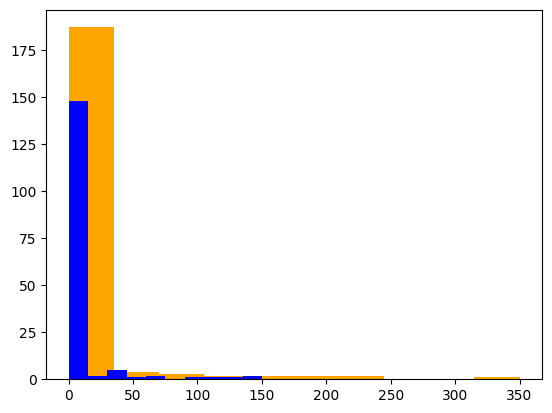

In [219]:
plt.hist(data.loc[(data["sex"] == "female") , "childcare"],color ='orange')
plt.hist(data.loc[(data["sex"] == "male") , "childcare"],color ='blue')


d1=data.loc[(data["sex"] == "female") , "childcare"]
m=d1.mean()
std=d1.std()
print(scipy.stats.kstest(d1,"norm",(m,std))[1])
d2=data.loc[(data["sex"] == "male") , "childcare"]
m=d2.mean()
std=d2.std()
print(scipy.stats.kstest(d2,"norm",(m,std))[1])

In [220]:
scipy.stats.mannwhitneyu(d1,d2)

MannwhitneyuResult(statistic=np.float64(16964.5), pvalue=np.float64(0.4557995757377217))

p>0.05 so there is no statistacally significalt difference between the two groups. In regards to childcare

In [221]:
data.groupby("sex")["childcare"].sum()

C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\518613725.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sex")["childcare"].sum()


sex
male      1040
female    2370
Name: childcare, dtype: int64

<h2>Sleeping<h2>

(array([ 3.,  2.,  1.,  9., 32., 64., 35., 12.,  3.,  2.]),
 array([  0.,  92., 184., 276., 368., 460., 552., 644., 736., 828., 920.]),
 <BarContainer object of 10 artists>)

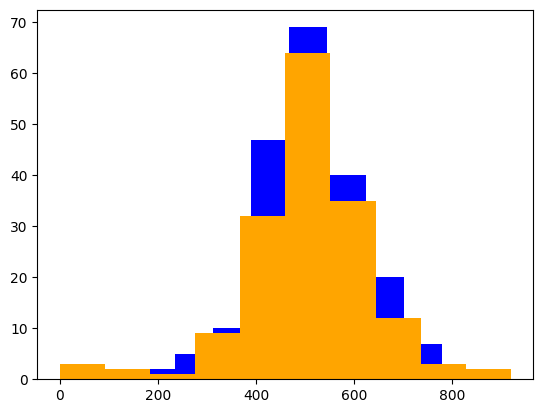

In [222]:
plt.hist(data[data["sex"]=="female"]["sleeping"],color ='blue')
plt.hist(data[data["sex"]=="male"]["sleeping"],color ='orange')

In [223]:
d1=data.loc[(data["sex"] == "female") , "sleeping"]
m=d1.mean()
std=d1.std()
print(scipy.stats.kstest(d1,"norm",(m,std))[1])
d2=data.loc[(data["sex"] == "male") , "sleeping"]
m=d2.mean()
std=d2.std()
print(scipy.stats.kstest(d2,"norm",(m,std))[1])

0.07782063598624245
0.14297163224169296


Based on Kolmogorow-Smirnov test p>0.05 and visual inspection the data is normally distributed. (and not paired and thus we can use t-test to find if there are statistical differences)

In [224]:
scipy.stats.ttest_ind(d1,d2)

TtestResult(statistic=np.float64(-0.031395179978942346), pvalue=np.float64(0.9749715920995812), df=np.float64(364.0))

p>0.05 an so there are no statistacally significant diffrences with regards to sleeping between the sexes

In [225]:
data.groupby("sex")["sleeping"].sum()

C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\3361491928.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sex")["sleeping"].sum()


sex
male       82000
female    102040
Name: sleeping, dtype: int64

<h2>Studying<h2>

1.9153690356513497e-54
nan


C:\Users\hirvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_distn_infrastructure.py:2110: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


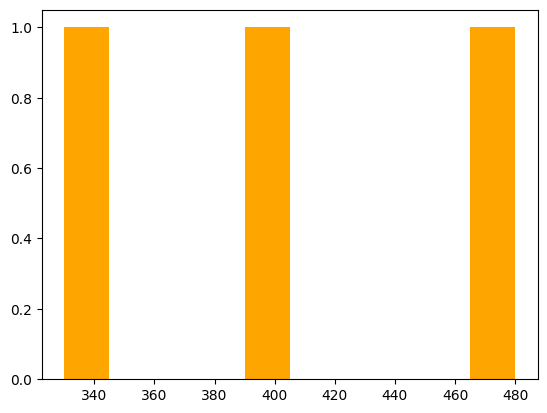

In [226]:
#plt.hist(data[data["sex"]=="female"]["studying in school"],color ='blue')
plt.hist(data.loc[(data["sex"] == "female") & (data["studying in school"] > 0), "studying in school"], color='orange')
d1=data.loc[(data["sex"] == "female") , "studying in school"]
m=d1.mean()
std=d1.std()
print(scipy.stats.kstest(d1,"norm",(m,std))[1])
d2=data.loc[(data["sex"] == "male") , "studying in school"]
m=d2.mean()
std=d2.std()
print(scipy.stats.kstest(d2,"norm",(m,std))[1])

There are no men in the data who are currently studying

In [227]:
data.groupby("sex")["studying in school"].sum()

C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\2636187199.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sex")["studying in school"].sum()


sex
male         0
female    1200
Name: studying in school, dtype: int64

Cinema

In [228]:
data.groupby("sex")["cinema"].count()

C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\2873114007.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("sex")["cinema"].count()


sex
male      163
female    203
Name: cinema, dtype: int64

Sleeping

<h2>cinema<h2>

In [229]:
data.loc[data['cinema'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()

C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\2215824277.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['cinema'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()
C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\2215824277.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['cinema'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()


,kohde,jasen,day of week,age group,living environment,working,childcare,sleeping,studying in school,cinema,library
sex,,,,,,,,,,,
male,0.380368,0.380368,0.380368,0.380368,0.380368,0.380368,0.380368,0.380368,0.380368,0.380368,0.380368
female,0.502463,0.502463,0.502463,0.502463,0.502463,0.502463,0.502463,0.502463,0.502463,0.502463,0.502463


A larger percentage of women visited cinema than men during the observation period

<h2>library<h2>

In [230]:
data.loc[data['library'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()

C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\1533313241.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['library'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()
C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\1533313241.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['library'] == 'visited'].groupby('sex').count()/data.groupby("sex").count()


,kohde,jasen,day of week,age group,living environment,working,childcare,sleeping,studying in school,cinema,library
sex,,,,,,,,,,,
male,0.595092,0.595092,0.595092,0.595092,0.595092,0.595092,0.595092,0.595092,0.595092,0.595092,0.595092
female,0.729064,0.729064,0.729064,0.729064,0.729064,0.729064,0.729064,0.729064,0.729064,0.729064,0.729064


A larger percentage of women visited library than men during the observation period


# <h1>Question 4: With respect to which activities do living environments differ?<h1>

working

(array([41.,  1.,  1.,  2.,  2.,  6.,  5.,  0.,  0.,  1.]),
 array([  0.,  79., 158., 237., 316., 395., 474., 553., 632., 711., 790.]),
 <BarContainer object of 10 artists>)

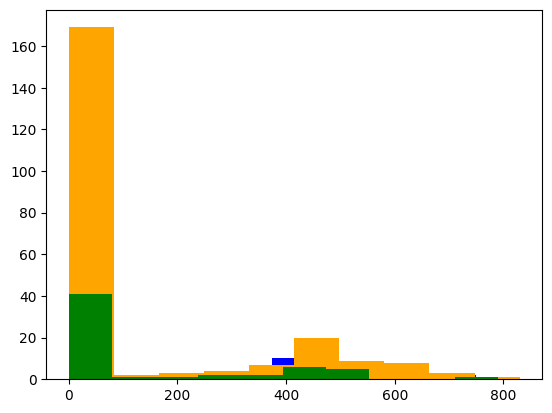

In [231]:
plt.hist(data[data["living environment"]=="rural"]["working"],color ='blue')
plt.hist(data[data["living environment"]=="city"]["working"],color ='orange')
plt.hist(data[data["living environment"]=="munipality"]["working"],color ='green')

6.976323136070437e-12
7.095663172256527e-41
1.2131645998610011e-08


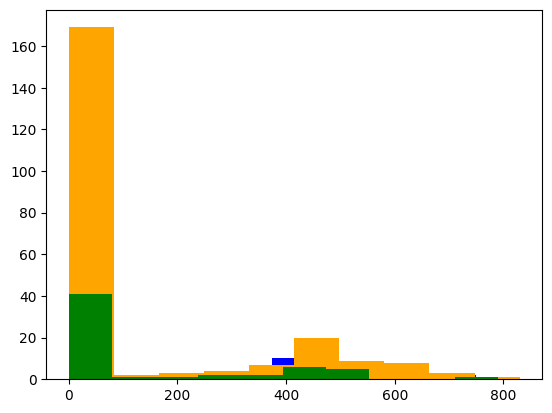

In [232]:
plt.hist(data[data["living environment"]=="rural"]["working"],color ='blue')
plt.hist(data[data["living environment"]=="city"]["working"],color ='orange')
plt.hist(data[data["living environment"]=="munipality"]["working"],color ='green')

d1=data.loc[(data["living environment"] == "rural") , "working"]
m=d1.mean()
std=d1.std()
print(scipy.stats.kstest(d1,"norm",(m,std))[1])
d2=data.loc[(data["living environment"] == "city") , "working"]
m=d2.mean()
std=d2.std()
print(scipy.stats.kstest(d2,"norm",(m,std))[1])

d3=data.loc[(data["living environment"] == "munipality")  , "working"]
m=d3.mean()
std=d3.std()
print(scipy.stats.kstest(d3,"norm",(m,std))[1])

Only the city data is normally distributed so we will use Kruskal-Wallis test.

In [233]:
stats.kruskal(d1,d2,d3)

KruskalResult(statistic=np.float64(2.1691736712677128), pvalue=np.float64(0.3380414237166005))

P>0.05 so there is not statistical difference between the three living enviroments in regards to working

childcare

(array([70.,  2.,  3.,  1.,  1.,  1.,  0.,  1.,  1.,  1.]),
 array([  0.,  19.,  38.,  57.,  76.,  95., 114., 133., 152., 171., 190.]),
 <BarContainer object of 10 artists>)

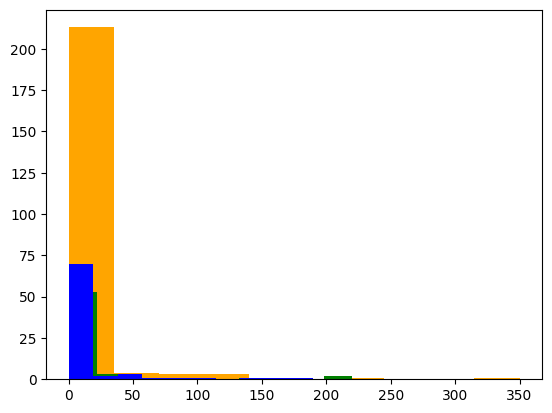

In [234]:

plt.hist(data[data["living environment"]=="city"]["childcare"],color ='orange')
plt.hist(data[data["living environment"]=="munipality"]["childcare"],color ='green')
plt.hist(data[data["living environment"]=="rural"]["childcare"],color ='blue')

8.917981878736031e-18
3.2052085756616205e-49
1.649462946301162e-13


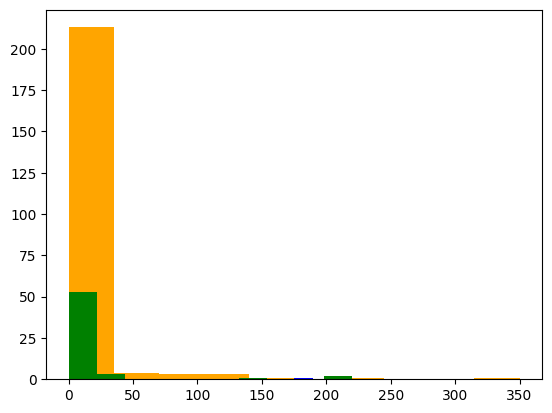

In [235]:
plt.hist(data[data["living environment"]=="rural"]["childcare"],color ='blue')
plt.hist(data[data["living environment"]=="city"]["childcare"],color ='orange')
plt.hist(data[data["living environment"]=="munipality"]["childcare"],color ='green')

d1=data.loc[(data["living environment"] == "rural") , "childcare"]
m=d1.mean()
std=d1.std()
print(scipy.stats.kstest(d1,"norm",(m,std))[1])
d2=data.loc[(data["living environment"] == "city") , "childcare"]
m=d2.mean()
std=d2.std()
print(scipy.stats.kstest(d2,"norm",(m,std))[1])

d3=data.loc[(data["living environment"] == "munipality")  , "childcare"]
m=d3.mean()
std=d3.std()
print(scipy.stats.kstest(d3,"norm",(m,std))[1])

In [236]:
stats.kruskal(d1,d2,d3)

KruskalResult(statistic=np.float64(1.1600726832026547), pvalue=np.float64(0.5598780193319083))

P>0.05 there is no statistically significant difference between the living areas in regards to childcare

sleeping

(array([ 2.,  0.,  1.,  5.,  8., 15., 18., 16., 10.,  6.]),
 array([110., 171., 232., 293., 354., 415., 476., 537., 598., 659., 720.]),
 <BarContainer object of 10 artists>)

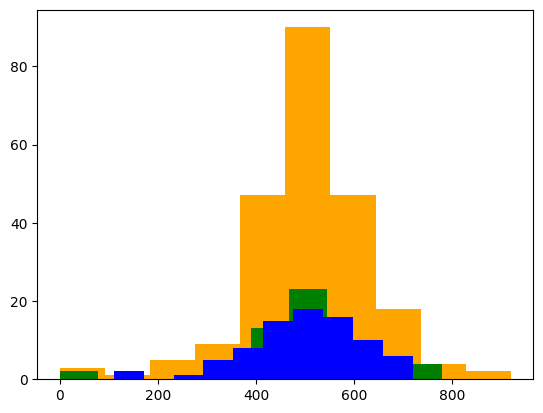

In [237]:

plt.hist(data[data["living environment"]=="city"]["sleeping"],color ='orange')
plt.hist(data[data["living environment"]=="munipality"]["sleeping"],color ='green')
plt.hist(data[data["living environment"]=="rural"]["sleeping"],color ='blue')

0.5940724181535185
0.05865846669486019
0.1361958723495329


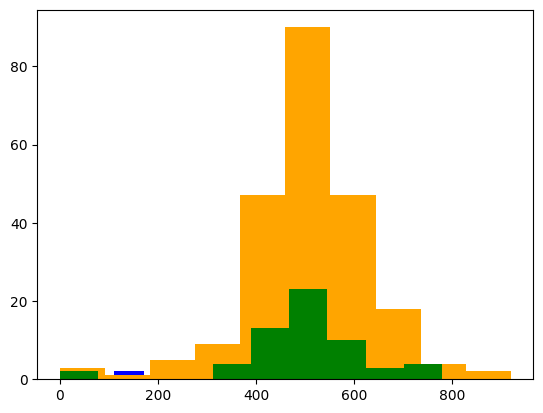

In [238]:
plt.hist(data[data["living environment"]=="rural"]["sleeping"],color ='blue')
plt.hist(data[data["living environment"]=="city"]["sleeping"],color ='orange')
plt.hist(data[data["living environment"]=="munipality"]["sleeping"],color ='green')

d1=data.loc[(data["living environment"] == "rural") , "sleeping"]
m=d1.mean()
std=d1.std()
print(scipy.stats.kstest(d1,"norm",(m,std))[1])
d2=data.loc[(data["living environment"] == "city") , "sleeping"]
m=d2.mean()
std=d2.std()
print(scipy.stats.kstest(d2,"norm",(m,std))[1])

d3=data.loc[(data["living environment"] == "munipality")  , "sleeping"]
m=d3.mean()
std=d3.std()
print(scipy.stats.kstest(d3,"norm",(m,std))[1])

All the variables are normally distributed so ANOVA test is appropriate.

In [239]:
d1 = d1.reset_index(drop=True) 
d2 = d2.reset_index(drop=True) 
d3 = d3.reset_index(drop=True)
df=pd.DataFrame({'city':d1,'munipality':d2,'rural':d3})
print(df)
mdata=pd.melt(df,value_vars=['city','munipality','rural'])
mdata.columns=['dataset','value']
mdata=mdata.dropna()
print(mdata)



model=statsmodels.formula.api.ols('value~C(dataset)',mdata).fit()
model

      city  munipality  rural
0    430.0         560  530.0
1    450.0         440  720.0
2    560.0         570  640.0
3    500.0         190  590.0
4    480.0         600  460.0
..     ...         ...    ...
221    NaN         560    NaN
222    NaN         660    NaN
223    NaN         460    NaN
224    NaN         470    NaN
225    NaN         740    NaN

[226 rows x 3 columns]
    dataset  value
0      city  430.0
1      city  450.0
2      city  560.0
3      city  500.0
4      city  480.0
..      ...    ...
506   rural  570.0
507   rural  660.0
508   rural  470.0
509   rural  480.0
510   rural    0.0

[366 rows x 2 columns]


In [240]:
print(statsmodels.api.stats.anova_lm(model,typ=1))

               df        sum_sq       mean_sq         F    PR(>F)
C(dataset)    2.0  6.391299e+03   3195.649413  0.209592  0.811013
Residual    363.0  5.534654e+06  15246.979366       NaN       NaN


p>0.05 so there is no statistically significant difference in the datasets

studying in school

(array([ 0.,  0.,  0.,  0.,  0., 81.,  0.,  0.,  0.,  0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

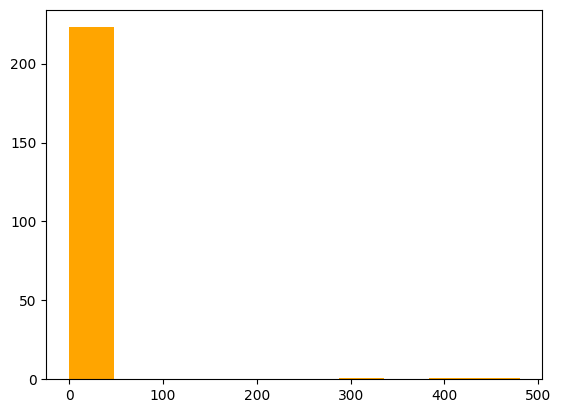

In [241]:

plt.hist(data[data["living environment"]=="city"]["studying in school"],color ='orange')
plt.hist(data[data["living environment"]=="munipality"]["studying in school"],color ='green')
plt.hist(data[data["living environment"]=="rural"]["studying in school"],color ='blue')

nan
2.640171300754442e-60
nan


C:\Users\hirvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_distn_infrastructure.py:2110: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


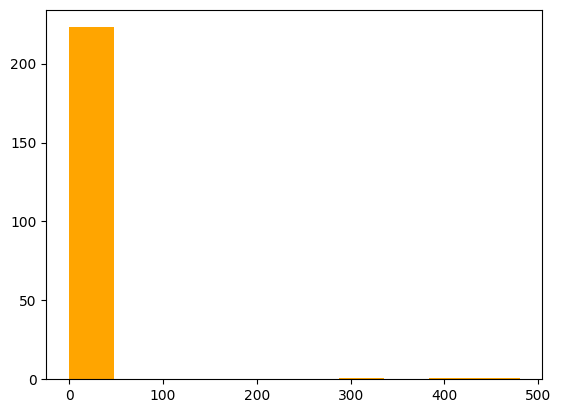

In [242]:

plt.hist(data[data["living environment"]=="city"]["studying in school"],color ='orange')
plt.hist(data[data["living environment"]=="munipality"]["studying in school"],color ='green')
plt.hist(data[data["living environment"]=="rural"]["studying in school"],color ='blue')

d1=data.loc[(data["living environment"] == "rural") , "studying in school"]
m=d1.mean()
std=d1.std()
print(scipy.stats.kstest(d1,"norm",(m,std))[1])
d2=data.loc[(data["living environment"] == "city") , "studying in school"]
m=d2.mean()
std=d2.std()
print(scipy.stats.kstest(d2,"norm",(m,std))[1])

d3=data.loc[(data["living environment"] == "munipality")  , "studying in school"]
m=d3.mean()
std=d3.std()
print(scipy.stats.kstest(d3,"norm",(m,std))[1])

In [243]:
print(data.loc[(data["living environment"] == "city") &(data["studying in school"] >0), "studying in school"].count())
print(data.loc[(data["living environment"] == "munipality") &(data["studying in school"] >0), "studying in school"].count())
print(data.loc[(data["living environment"] == "rural") &(data["studying in school"] >0), "studying in school"].count())

3
0
0


Only city had people in school

library

In [244]:
data.loc[data['library'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()

C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\1211913492.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['library'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()
C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\1211913492.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['library'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()


,kohde,jasen,day of week,sex,age group,working,childcare,sleeping,studying in school,cinema,library
living environment,,,,,,,,,,,
city,0.668142,0.668142,0.668142,0.668142,0.668142,0.668142,0.668142,0.668142,0.668142,0.668142,0.668142
munipality,0.711864,0.711864,0.711864,0.711864,0.711864,0.711864,0.711864,0.711864,0.711864,0.711864,0.711864
rural,0.641975,0.641975,0.641975,0.641975,0.641975,0.641975,0.641975,0.641975,0.641975,0.641975,0.641975


cinema

In [245]:
data.loc[data['cinema'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()

C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\2560204527.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['cinema'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()
C:\Users\hirvi\AppData\Local\Temp\ipykernel_66968\2560204527.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.loc[data['cinema'] == 'visited'].groupby('living environment').count()/data.groupby("living environment").count()


,kohde,jasen,day of week,sex,age group,working,childcare,sleeping,studying in school,cinema,library
living environment,,,,,,,,,,,
city,0.504425,0.504425,0.504425,0.504425,0.504425,0.504425,0.504425,0.504425,0.504425,0.504425,0.504425
munipality,0.457627,0.457627,0.457627,0.457627,0.457627,0.457627,0.457627,0.457627,0.457627,0.457627,0.457627
rural,0.283951,0.283951,0.283951,0.283951,0.283951,0.283951,0.283951,0.283951,0.283951,0.283951,0.283951


Rural people used cinema much less than people living in munipality or city

There were was a statistically significant difference in working activity between men and women. No men were studiyng in the cleaned dataset.
About 10% more of the women had visited the library and same for the cinema.  Other than that there were no statistically significant differences.


Only city had people studying. 30% of people from rural areas visited cinema as opposed to about 45% of the people from city and munipalities. people from munipalities used the library most 68% followed by rural 64% and city 61% Other than that there were no statistically significant differences.

# <h1>Question 5: Which activities are associated with each other? <h1>

In [249]:
activity_columns = ["working", "childcare", "sleeping", "studying in school"]

In [262]:
# Compute the pairwise correlation coefficients between the activity variables to quantify their relationships.
correlation_matrix = data[activity_columns].corr()

In [263]:
print("Correlation matrix for activities:")
print(correlation_matrix)

Correlation matrix for activities:
                     working  childcare  sleeping  studying in school
working             1.000000  -0.016732 -0.235553           -0.053033
childcare          -0.016732   1.000000  0.012528           -0.023251
sleeping           -0.235553   0.012528  1.000000           -0.043146
studying in school -0.053033  -0.023251 -0.043146            1.000000


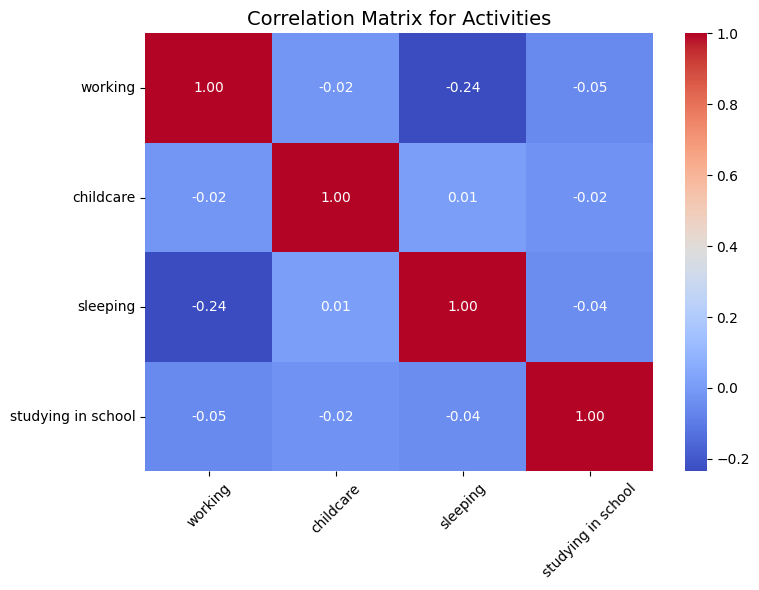

In [264]:
# Display the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Matrix for Activities", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The heat map generated revealed the relationship between activities based on their pairwise correlation coefficients. We used the heatmap because it is an efficient way of visualizing the relationship between different variables. It helps to give a positive, negative, and negligible correlation between different variables at the same time using different colors. Pearson correlation gives a linear correlation.

In this analysis: 

 
Working has a negative correlation with sleeping (-0.24). This means that the individual who spends more time working spends less time sleeping, but this relationship is not strong. 

Every other activity pair such as working and childcare, working and studying in school and others have a correlation close to 0 which means that there is no meaningful relationship between these activities. 

Sleeping and studying have a very slight negative correlation (-0.04) but this is too weak to be significant. 

 

In conclusion, the heat map shows that these selected activities are largely independent. There is only a weak negative relationship between working and sleeping duration, which suggests that the activities analyzed are not strongly interrelated in terms of time allocation. 